# 05 — Spp1 and Cd44 by treatment condition (single-cell)

*"Who makes Spp1 and who carries Cd44, in each treatment arm, and how does it move with
treatment?"* — answered in **single-cell** (`annotation_v4.h5ad`), which is dissociated and so
carries **no segmentation spillover**. This is the clean per-condition ligand/receptor readout
that the spatial data cannot give.

### Design (from `obs['file_name']`, convention `<condition>_Tu<loc>_<rep>`)
| | |
|---|---|
| **NoTx** | untreated |
| **CyTAG72** | cyclophosphamide + **non-specific** (TAG72) CAR-T |
| **CyPSCA** | cyclophosphamide + **PSCA-specific** CAR-T |
| **RTCyTAG72** | radiation + Cy + non-specific CAR-T |
| **RTCyPSCA** | radiation + Cy + PSCA CAR-T  ← the arm of interest |

`Tu1` = the irradiated tumour (in RT arms), `Tu2` = the **abscopal** tumour, never irradiated.
3 replicates per arm (29 of 30 samples present).

### Two things this notebook is built around
1. **Same rep number = same mouse.** `X_Tu1_2` and `X_Tu2_2` are two tumours from one animal, so
   Tu1-vs-Tu2 is tested **paired within-mouse** (§6) — much more sensitive at n=3, and the
   cleanest statement of the abscopal effect.
2. **Contribution = abundance x per-cell expression.** A cell type's share of the Spp1 pool can
   rise because there are more of them or because each makes more. §5 splits every change into
   those two drivers, because they are different biology.

### Units
Pool/contribution maths uses **linear CP10K** (`expm1` of the log-normalised `.X`), not log
values: log values are not additive, so summing them does not give a transcript pool. CP10K is
also depth-normalised per cell, so it compares across samples better than raw counts would.

In [13]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

import scanpy as sc

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80); pd.set_option("display.width", 240)

## 1. Config

In [14]:
SC_REF  = Path("/coh_labs/yunroseli/Jona/CAR-T/data/zarr/fullDataset/"
               "annotating_references/annotation_v4.h5ad")
OUT_DIR = Path("/coh_labs/yunroseli/Jona/CAR-T/results/spp1_analysis")
FIG_DIR = OUT_DIR / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True); FIG_DIR.mkdir(parents=True, exist_ok=True)

SAMPLE_COL   = "file_name"
TUMOUR_LABEL = "Cancer_cell"
MAC_LABELS   = ["M1_like_Mac", "M2_like_Mac", "Intermediate_Mac"]
GENES        = ["Spp1", "Cd44"]

CONDITION_ORDER = ["NoTx", "CyTAG72", "CyPSCA", "RTCyTAG72", "RTCyPSCA"]
COND_META = {   # what each arm actually is, so contrasts can be built from attributes
    "NoTx":      {"RT": False, "cart": "none",        "cy": False},
    "CyTAG72":   {"RT": False, "cart": "nonspecific", "cy": True},
    "CyPSCA":    {"RT": False, "cart": "PSCA",        "cy": True},
    "RTCyTAG72": {"RT": True,  "cart": "nonspecific", "cy": True},
    "RTCyPSCA":  {"RT": True,  "cart": "PSCA",        "cy": True},
}
MIN_CELLS_CT = 20      # min cells of a type in a sample before its per-cell mean is reported
TOP_N_CT     = 10      # cell types shown individually in the stacked composition bars

assert SC_REF.exists(), f"reference not found: {SC_REF}"
print("config ready ->", OUT_DIR)

config ready -> /coh_labs/yunroseli/Jona/CAR-T/results/spp1_analysis


## 2. Load, detect the annotation level, parse the design

In [15]:
scref = sc.read_h5ad(SC_REF)

lvl_cols = [c for c in scref.obs.columns if c.startswith("cell_type_lvl")]
want = set(MAC_LABELS) | {TUMOUR_LABEL}
CT_COL = max(lvl_cols, key=lambda c: len(set(scref.obs[c].astype(str)) & want))
sc_ct = scref.obs[CT_COL].astype(str)
print(f"cells: {scref.n_obs:,} | genes: {scref.n_vars:,} | using {CT_COL}")

# normalise a working copy if .X is raw counts (same check as 01d)
X = scref.X
head = X[:200].toarray() if sp.issparse(X) else X[:200]
if bool(np.allclose(head, np.round(head))) and float(X.max()) > 50:
    scref.layers["counts"] = scref.X.copy()
    sc.pp.normalize_total(scref, target_sum=1e4); sc.pp.log1p(scref)
    print("normalized raw counts -> CP10K + log1p")
else:
    print(".X already log-normalized")

assert SAMPLE_COL in scref.obs.columns, f"{SAMPLE_COL} not in obs"
for g in GENES:
    assert g in scref.var_names, f"{g} not in var_names"

def parse_sample(fn):
    """<condition>_Tu<loc>_<rep>  ->  (condition, tumour_loc, replicate)."""
    m = re.match(r"^(.*)_Tu(\d+)_(\d+)$", str(fn))
    return (m.group(1), int(m.group(2)), int(m.group(3))) if m else (None, None, None)

samples = scref.obs[SAMPLE_COL].astype(str)
parsed = samples.map(parse_sample)
scref.obs["cond"]      = [p[0] for p in parsed]
scref.obs["tumor_loc"] = [p[1] for p in parsed]
scref.obs["rep"]       = [p[2] for p in parsed]
bad = scref.obs["cond"].isna().sum()
assert bad == 0, f"{bad} cells have a file_name that does not match <cond>_Tu<loc>_<rep>"

scref.obs["mouse"]    = scref.obs["cond"] + "_rep" + scref.obs["rep"].astype(str)   # Tu1+Tu2 share a mouse
scref.obs["group"]    = scref.obs["cond"] + "_Tu" + scref.obs["tumor_loc"].astype(str)
scref.obs["rt_group"] = np.where(
    ~scref.obs["cond"].map(lambda c: COND_META.get(c, {}).get("RT", False)), "no_RT",
    np.where(scref.obs["tumor_loc"] == 1, "RT_direct", "RT_abscopal"))

design = (scref.obs.groupby([SAMPLE_COL, "cond", "tumor_loc", "rep", "mouse", "rt_group"],
                            observed=True).size().rename("n_cells").reset_index())
design.to_csv(OUT_DIR / "sc_design_table.csv", index=False)
print(f"\n=== design: {len(design)} samples, {design['mouse'].nunique()} mice ===")
print(design.pivot_table(index="cond", columns="tumor_loc", values="n_cells",
                         aggfunc=["count", "sum"]).to_string())
missing = [f"{c}_Tu{t}_{r}" for c in CONDITION_ORDER for t in (1, 2) for r in (1, 2, 3)
           if not ((design["cond"] == c) & (design["tumor_loc"] == t) & (design["rep"] == r)).any()]
print(f"\nmissing samples ({len(missing)}): {missing if missing else 'none'}")
print("  -> groups containing a missing sample run at n=2; read their means accordingly.")

cells: 93,548 | genes: 22,949 | using cell_type_lvl2
.X already log-normalized

=== design: 29 samples, 15 mice ===
          count       sum       
tumor_loc     1  2      1      2
cond                            
CyPSCA        3  3   9985   5626
CyTAG72       2  3  10010  12233
NoTx          3  3   4157   3663
RTCyPSCA      3  3  12232   9781
RTCyTAG72     3  3  15440  10421

missing samples (1): ['CyTAG72_Tu1_2']
  -> groups containing a missing sample run at n=2; read their means accordingly.


## 3. Per-cell Spp1 and Cd44 in every sample

Per **sample** (the replicate unit), then averaged across replicates within condition x tumour.
`mean_per_cell` is the linear CP10K average over all cells; `pct_pos` is the detection rate.

In [16]:
def expr_log(gene):
    v = scref[:, gene].X
    return np.asarray(v.todense()).ravel() if sp.issparse(v) else np.asarray(v).ravel()

# linear CP10K -> additive, so it can be summed into a transcript pool
cell = pd.DataFrame({
    "sample": samples.values, "cond": scref.obs["cond"].values,
    "tumor_loc": scref.obs["tumor_loc"].values, "rep": scref.obs["rep"].values,
    "mouse": scref.obs["mouse"].values, "group": scref.obs["group"].values,
    "rt_group": scref.obs["rt_group"].values, "celltype": sc_ct.values,
})
for g in GENES:
    lg = expr_log(g)
    cell[f"{g}_log"] = lg
    cell[f"{g}_lin"] = np.expm1(lg)
    cell[f"{g}_pos"] = (cell[f"{g}_lin"] > 0).astype(float)

per_sample = (cell.groupby(["sample", "cond", "tumor_loc", "rep", "mouse", "group", "rt_group"],
                           observed=True)
              .agg(n_cells=("celltype", "size"),
                   **{f"{g}_mean_per_cell": (f"{g}_lin", "mean") for g in GENES},
                   **{f"{g}_pct_pos": (f"{g}_pos", "mean") for g in GENES})
              .reset_index())
for g in GENES:
    per_sample[f"{g}_pct_pos"] *= 100
per_sample.to_csv(OUT_DIR / "sc_spp1_cd44_per_sample.csv", index=False)

by_group = (per_sample.groupby(["cond", "tumor_loc", "group", "rt_group"], observed=True)
            .agg(n_reps=("sample", "count"), n_cells=("n_cells", "sum"),
                 **{f"{g}_mean": (f"{g}_mean_per_cell", "mean") for g in GENES},
                 **{f"{g}_sd": (f"{g}_mean_per_cell", "std") for g in GENES},
                 **{f"{g}_pct_pos": (f"{g}_pct_pos", "mean") for g in GENES})
            .reset_index())
by_group["cond"] = pd.Categorical(by_group["cond"], CONDITION_ORDER, ordered=True)
by_group = by_group.sort_values(["cond", "tumor_loc"])
by_group.to_csv(OUT_DIR / "sc_spp1_cd44_by_condition.csv", index=False)

print("=== Spp1 / Cd44 per cell, by condition x tumour (mean of replicate means, CP10K) ===")
print(by_group.round(3).to_string(index=False))

=== Spp1 / Cd44 per cell, by condition x tumour (mean of replicate means, CP10K) ===
     cond  tumor_loc         group    rt_group  n_reps  n_cells  Spp1_mean  Cd44_mean  Spp1_sd  Cd44_sd  Spp1_pct_pos  Cd44_pct_pos
     NoTx          1      NoTx_Tu1       no_RT       3     4157  25.096001      8.961    6.443    0.581        73.342        77.761
     NoTx          2      NoTx_Tu2       no_RT       3     3663  19.757999      6.376    5.239    1.562        70.070        62.812
  CyTAG72          1   CyTAG72_Tu1       no_RT       2    10010   4.590000      5.439    1.917    0.795        54.236        87.760
  CyTAG72          2   CyTAG72_Tu2       no_RT       3    12233   7.685000      5.873    3.096    2.037        72.392        88.453
   CyPSCA          1    CyPSCA_Tu1       no_RT       3     9985   3.007000      7.831    0.780    2.520        50.610        88.767
   CyPSCA          2    CyPSCA_Tu2       no_RT       3     5626   4.767000      9.171    2.546    5.606        63.962      

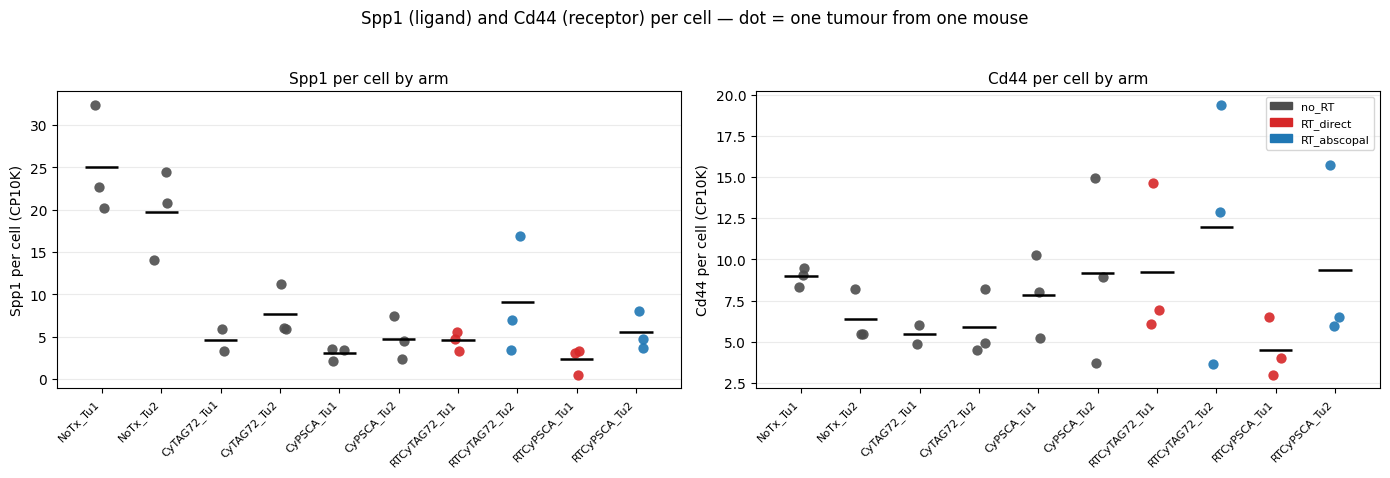

In [17]:
# Replicate dot plot: each dot is one mouse's tumour.
groups = [f"{c}_Tu{t}" for c in CONDITION_ORDER for t in (1, 2)]
groups = [g for g in groups if g in set(per_sample["group"])]
xmap = {g: i for i, g in enumerate(groups)}
colors = {"no_RT": "#4d4d4d", "RT_direct": "#d62728", "RT_abscopal": "#1f77b4"}
rng = np.random.default_rng(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
for ax, g in zip(axes, GENES):
    for grp in groups:
        s = per_sample[per_sample["group"] == grp]
        v = s[f"{g}_mean_per_cell"].values
        ax.scatter(xmap[grp] + rng.uniform(-0.12, 0.12, len(v)), v, s=55,
                   color=colors.get(s["rt_group"].iloc[0] if len(s) else "no_RT", "k"),
                   alpha=0.9, linewidths=0, zorder=3)
        if len(v):
            ax.hlines(np.mean(v), xmap[grp] - 0.28, xmap[grp] + 0.28, color="k", lw=1.8, zorder=4)
    ax.set_xticks(list(xmap.values())); ax.set_xticklabels(groups, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel(f"{g} per cell (CP10K)"); ax.set_title(f"{g} per cell by arm", fontsize=11)
    ax.grid(axis="y", alpha=0.25)
from matplotlib.patches import Patch
axes[1].legend(handles=[Patch(color=c, label=k) for k, c in colors.items()], fontsize=8, loc="best")
fig.suptitle("Spp1 (ligand) and Cd44 (receptor) per cell — dot = one tumour from one mouse", y=1.03)
fig.tight_layout(); fig.savefig(FIG_DIR / "sc_spp1_cd44_per_condition.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close(fig)

## 4. Composition — who makes the Spp1, and who carries the Cd44, in each arm?

Two complementary readouts per sample, aggregated across replicates:

- **`pct_of_pool`** — share of the sample's total Spp1 (or Cd44) CP10K contributed by each cell
  type. This is *contribution*: it already folds in how common the cell type is.
- **`pct_of_pos_cells`** — of the cells that are positive for the gene, what fraction are this
  type. The intuitive *composition* view.

In [18]:
rows = []
for (samp, cond, tloc, grp), d in cell.groupby(["sample", "cond", "tumor_loc", "group"], observed=True):
    n_tot = len(d)
    for g in GENES:
        tot = d[f"{g}_lin"].sum()
        pos = d[f"{g}_lin"] > 0
        for ctn, dd in d.groupby("celltype", observed=True):
            rows.append({
                "sample": samp, "cond": cond, "tumor_loc": tloc, "group": grp, "gene": g,
                "celltype": ctn, "n_cells": len(dd), "pct_of_cells": 100 * len(dd) / n_tot,
                "pct_of_pool": 100 * dd[f"{g}_lin"].sum() / tot if tot > 0 else np.nan,
                "pct_of_pos_cells": 100 * (dd[f"{g}_lin"] > 0).sum() / pos.sum() if pos.sum() else np.nan,
                "mean_per_cell": dd[f"{g}_lin"].mean() if len(dd) >= MIN_CELLS_CT else np.nan,
            })
comp = pd.DataFrame(rows)
comp.to_csv(OUT_DIR / "sc_spp1_cd44_composition_per_sample.csv", index=False)

comp_grp = (comp.groupby(["gene", "cond", "tumor_loc", "group", "celltype"], observed=True)
            .agg(n_reps=("sample", "count"), pct_of_cells=("pct_of_cells", "mean"),
                 pct_of_pool=("pct_of_pool", "mean"), pct_of_pool_sd=("pct_of_pool", "std"),
                 pct_of_pos_cells=("pct_of_pos_cells", "mean"),
                 mean_per_cell=("mean_per_cell", "mean"))
            .reset_index())
comp_grp["cond"] = pd.Categorical(comp_grp["cond"], CONDITION_ORDER, ordered=True)
comp_grp = comp_grp.sort_values(["gene", "cond", "tumor_loc", "pct_of_pool"],
                                ascending=[True, True, True, False])
comp_grp.to_csv(OUT_DIR / "sc_spp1_cd44_composition_by_condition.csv", index=False)

for g in GENES:
    piv = (comp_grp[comp_grp["gene"] == g]
           .pivot_table(index="celltype", columns="group", values="pct_of_pool", observed=True))
    piv = piv.reindex(columns=[c for c in groups if c in piv.columns])
    piv = piv.loc[piv.mean(axis=1).sort_values(ascending=False).index]
    print(f"\n=== % of the {g} pool contributed by each cell type, per arm ===")
    print(piv.round(2).to_string())


=== % of the Spp1 pool contributed by each cell type, per arm ===
group               NoTx_Tu1   NoTx_Tu2  CyTAG72_Tu1  CyTAG72_Tu2  CyPSCA_Tu1  CyPSCA_Tu2  RTCyTAG72_Tu1  RTCyTAG72_Tu2  RTCyPSCA_Tu1  RTCyPSCA_Tu2
celltype                                                                                                                                           
M2_like_Mac        40.360001  34.490002    70.959999    60.060001   51.919998   40.689999      54.939999      57.830002     46.290001     49.080002
Cancer_cell        45.000000  52.090000    13.650000    15.900000   16.860001   27.650000      19.270000      11.380000     28.809999     24.070000
Classical_Mono      3.250000   2.620000     7.520000    12.690000    9.620000   12.580000      12.890000      16.490000      8.420000     11.690000
M1_like_Mac         0.470000   0.630000     2.680000     3.570000    5.710000    8.390000       4.170000       4.600000      7.160000      5.720000
Intermediate_Mac    2.350000   1.330000     1

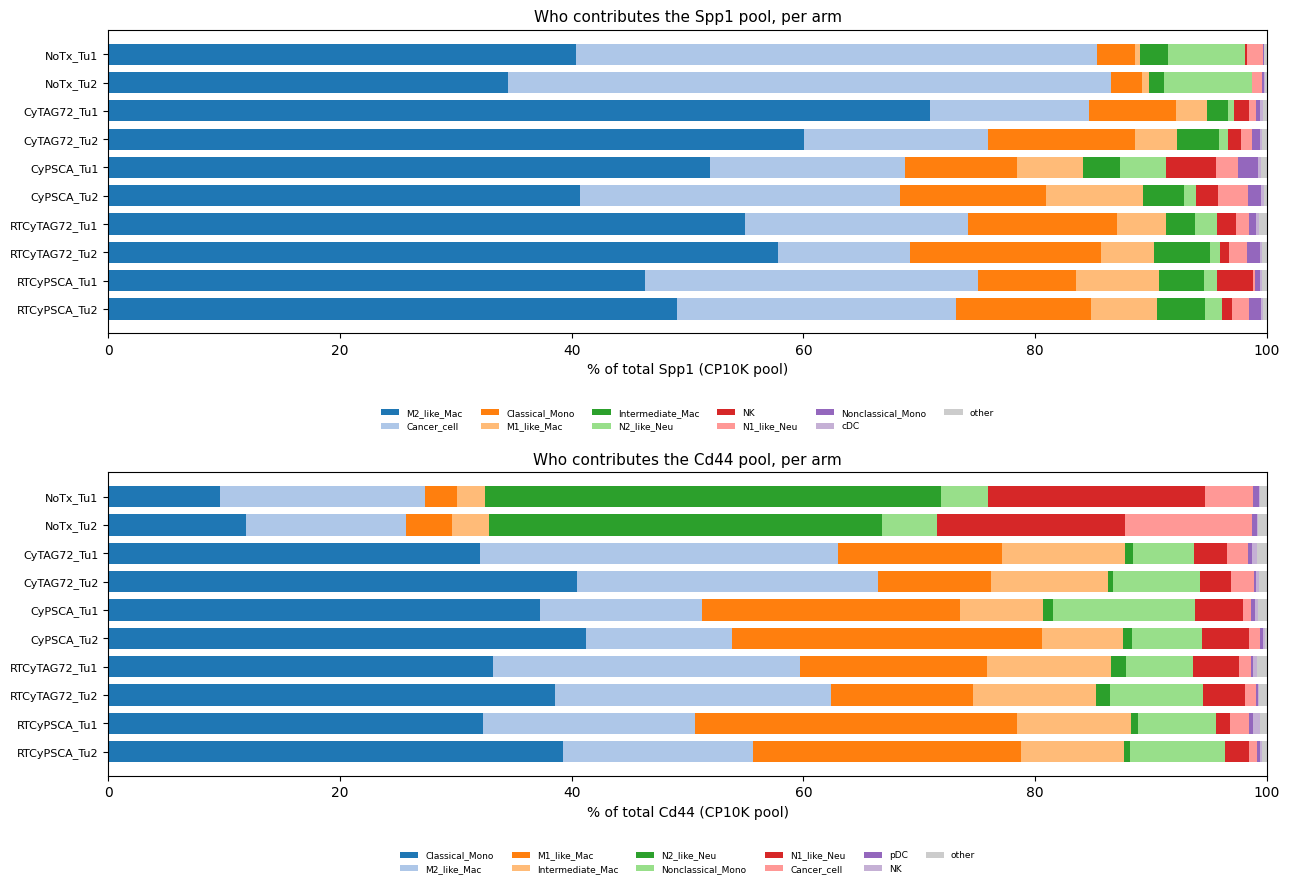

In [19]:
# Stacked composition bars: top cell types by mean pool share, rest folded into "other".
fig, axes = plt.subplots(2, 1, figsize=(13, 9))
for ax, g in zip(axes, GENES):
    piv = (comp_grp[comp_grp["gene"] == g]
           .pivot_table(index="group", columns="celltype", values="pct_of_pool", observed=True))
    piv = piv.reindex(index=[x for x in groups if x in piv.index]).fillna(0.0)
    top = piv.mean(axis=0).sort_values(ascending=False).head(TOP_N_CT).index.tolist()
    plot = piv[top].copy()
    plot["other"] = 100 - plot.sum(axis=1)
    cmap = plt.get_cmap("tab20")
    left = np.zeros(len(plot))
    for i, ctn in enumerate(plot.columns):
        ax.barh(range(len(plot)), plot[ctn].values, left=left,
                color=("0.8" if ctn == "other" else cmap(i % 20)), label=ctn, height=0.75)
        left += plot[ctn].values
    ax.set_yticks(range(len(plot))); ax.set_yticklabels(plot.index, fontsize=8)
    ax.invert_yaxis(); ax.set_xlim(0, 100); ax.set_xlabel(f"% of total {g} (CP10K pool)")
    ax.set_title(f"Who contributes the {g} pool, per arm", fontsize=11)
    ax.legend(fontsize=6.5, ncol=6, loc="upper center", bbox_to_anchor=(0.5, -0.22), frameon=False)
fig.tight_layout(); fig.savefig(FIG_DIR / "sc_spp1_cd44_composition.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close(fig)

## 5. Decomposition — did contribution move because of abundance, or per-cell output?

`pct_of_pool ~ pct_of_cells x mean_per_cell`. For each cell type, versus the **NoTx** baseline of
the same tumour location: the log2 change in abundance, in per-cell expression, and in overall
pool share. Which of the first two moves tells you *why* the third moved.

In [20]:
base_map = {t: f"NoTx_Tu{t}" for t in (1, 2)}
rows = []
for g in GENES:
    sub = comp_grp[comp_grp["gene"] == g]
    for tloc in (1, 2):
        base = sub[sub["group"] == base_map[tloc]].set_index("celltype")
        if base.empty:
            continue
        for grp in [x for x in groups if x.endswith(f"Tu{tloc}") and x != base_map[tloc]]:
            cur = sub[sub["group"] == grp].set_index("celltype")
            for ctn in cur.index.intersection(base.index):
                def lg2(a, b):
                    return float(np.log2(a / b)) if (a > 0 and b > 0 and np.isfinite(a) and np.isfinite(b)) else np.nan
                rows.append({
                    "gene": g, "group": grp, "tumor_loc": tloc, "celltype": ctn,
                    "log2_abundance": lg2(cur.loc[ctn, "pct_of_cells"], base.loc[ctn, "pct_of_cells"]),
                    "log2_per_cell":  lg2(cur.loc[ctn, "mean_per_cell"], base.loc[ctn, "mean_per_cell"]),
                    "log2_pool":      lg2(cur.loc[ctn, "pct_of_pool"], base.loc[ctn, "pct_of_pool"]),
                })
decomp = pd.DataFrame(rows)
decomp["driver"] = np.where(
    decomp[["log2_abundance", "log2_per_cell"]].isna().any(axis=1), "n/a",
    np.where(decomp["log2_abundance"].abs() > decomp["log2_per_cell"].abs(), "abundance", "per-cell"))
decomp.to_csv(OUT_DIR / "sc_spp1_cd44_decomposition_vs_NoTx.csv", index=False)

print("=== Spp1: change vs NoTx (same tumour loc) — macrophages + tumour ===")
focus = MAC_LABELS + [TUMOUR_LABEL]
d_show = decomp[(decomp["gene"] == "Spp1") & (decomp["celltype"].isin(focus))]
print(d_show.sort_values(["celltype", "group"])
      [["celltype", "group", "log2_abundance", "log2_per_cell", "log2_pool", "driver"]]
      .round(3).to_string(index=False))
print("\n  log2_pool up + driver='abundance' -> more of these cells, each making the same.")
print("  log2_pool up + driver='per-cell'  -> same number of cells, each making MORE (a state change).")

=== Spp1: change vs NoTx (same tumour loc) — macrophages + tumour ===
        celltype         group  log2_abundance  log2_per_cell  log2_pool    driver
     Cancer_cell    CyPSCA_Tu1          -2.142         -2.020     -1.417 abundance
     Cancer_cell    CyPSCA_Tu2          -2.682         -0.137     -0.914 abundance
     Cancer_cell   CyTAG72_Tu1          -2.238         -1.957     -1.721 abundance
     Cancer_cell   CyTAG72_Tu2          -3.037         -0.252     -1.712 abundance
     Cancer_cell  RTCyPSCA_Tu1          -2.442         -1.531     -0.643 abundance
     Cancer_cell  RTCyPSCA_Tu2          -3.005         -0.013     -1.114 abundance
     Cancer_cell RTCyTAG72_Tu1          -2.541         -1.140     -1.224 abundance
     Cancer_cell RTCyTAG72_Tu2          -3.264         -0.135     -2.194 abundance
Intermediate_Mac    CyPSCA_Tu1           1.304         -4.023      0.439  per-cell
Intermediate_Mac    CyPSCA_Tu2           1.404         -1.734      1.428  per-cell
Intermediate_Mac 

## 6. The abscopal axis — paired within-mouse Tu1 vs Tu2

Both tumours come from the **same animal**, so this is paired: for each mouse, Tu2 minus Tu1.
In the RT arms Tu1 was irradiated and Tu2 never was, so a consistent non-zero delta in
`RTCyPSCA` / `RTCyTAG72` — against a delta near zero in the non-RT arms — is the abscopal signal
in the Spp1/Cd44 axis.

In [21]:
wide = per_sample.pivot_table(index=["cond", "rep", "mouse"], columns="tumor_loc",
                              values=[f"{g}_mean_per_cell" for g in GENES], observed=True)
wide.columns = [f"{a}_Tu{b}" for a, b in wide.columns]
wide = wide.reset_index()
for g in GENES:
    a, b = f"{g}_mean_per_cell_Tu1", f"{g}_mean_per_cell_Tu2"
    if a in wide.columns and b in wide.columns:
        wide[f"{g}_delta_Tu2_minus_Tu1"] = wide[b] - wide[a]
        wide[f"{g}_log2_Tu2_over_Tu1"] = np.log2(wide[b] / wide[a]).replace([np.inf, -np.inf], np.nan)
wide.to_csv(OUT_DIR / "sc_spp1_cd44_paired_within_mouse.csv", index=False)

print("=== paired within-mouse (Tu2 = abscopal, Tu1 = irradiated in RT arms) ===")
print(wide.round(3).to_string(index=False))

# n_pairs counts mice with BOTH tumours present (a missing sample breaks the pair, so n_pairs < n_mice)
paired_summ = (wide.groupby("cond", observed=True)
               .agg(n_mice=("mouse", "count"),
                    **{f"{g}_n_pairs": (f"{g}_log2_Tu2_over_Tu1", "count") for g in GENES},
                    **{f"{g}_mean_log2_Tu2_over_Tu1": (f"{g}_log2_Tu2_over_Tu1", "mean") for g in GENES},
                    **{f"{g}_n_pos": (f"{g}_log2_Tu2_over_Tu1", lambda s: int((s > 0).sum())) for g in GENES})
               .reindex(CONDITION_ORDER).reset_index())
paired_summ.to_csv(OUT_DIR / "sc_spp1_cd44_paired_summary.csv", index=False)
print("\n--- mean log2(Tu2/Tu1) per arm; n_pairs = mice with BOTH tumours; n_pos = mice where Tu2 > Tu1 ---")
print(paired_summ.round(3).to_string(index=False))

=== paired within-mouse (Tu2 = abscopal, Tu1 = irradiated in RT arms) ===
     cond  rep          mouse  Cd44_mean_per_cell_Tu1  Cd44_mean_per_cell_Tu2  Spp1_mean_per_cell_Tu1  Spp1_mean_per_cell_Tu2  Spp1_delta_Tu2_minus_Tu1  Spp1_log2_Tu2_over_Tu1  Cd44_delta_Tu2_minus_Tu1  Cd44_log2_Tu2_over_Tu1
   CyPSCA    1    CyPSCA_rep1                   8.011               14.909000                3.518000                2.392000                    -1.127                  -0.557                     6.898                   0.896
   CyPSCA    2    CyPSCA_rep2                  10.256                3.707000                3.393000                7.454000                     4.061                   1.135                    -6.549                  -1.468
   CyPSCA    3    CyPSCA_rep3                   5.226                8.898000                2.109000                4.455000                     2.346                   1.079                     3.672                   0.768
  CyTAG72    1   CyTAG

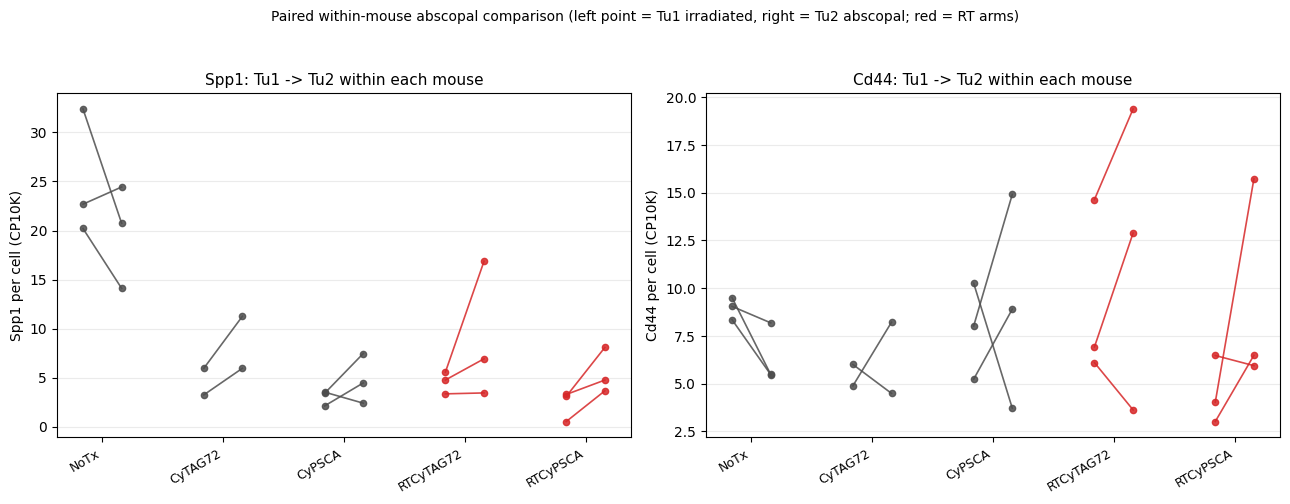

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for ax, g in zip(axes, GENES):
    a, b = f"{g}_mean_per_cell_Tu1", f"{g}_mean_per_cell_Tu2"
    for i, cnd in enumerate([c for c in CONDITION_ORDER if c in set(wide["cond"])]):
        s = wide[wide["cond"] == cnd]
        col = "#d62728" if COND_META.get(cnd, {}).get("RT") else "#4d4d4d"
        for _, r in s.iterrows():
            if np.isfinite(r.get(a, np.nan)) and np.isfinite(r.get(b, np.nan)):
                ax.plot([i - 0.16, i + 0.16], [r[a], r[b]], "-o", color=col, ms=4.5, lw=1.2, alpha=0.85)
    ax.set_xticks(range(len([c for c in CONDITION_ORDER if c in set(wide["cond"])])))
    ax.set_xticklabels([c for c in CONDITION_ORDER if c in set(wide["cond"])], rotation=30, ha="right", fontsize=9)
    ax.set_ylabel(f"{g} per cell (CP10K)")
    ax.set_title(f"{g}: Tu1 -> Tu2 within each mouse", fontsize=11)
    ax.grid(axis="y", alpha=0.25)
fig.suptitle("Paired within-mouse abscopal comparison (left point = Tu1 irradiated, right = Tu2 abscopal;"
             " red = RT arms)", y=1.04, fontsize=10)
fig.tight_layout(); fig.savefig(FIG_DIR / "sc_spp1_cd44_paired_abscopal.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close(fig)

## 7. Treatment contrasts, and per-cell-type expression heatmaps

Replicate-level contrasts built from the arm attributes. n=3 (n=2 where a sample is missing), so
these report **effect size and consistency**, not p-values — at this n a p-value is not
informative and would only invite over-reading.

In [23]:
def contrast(metric, a_groups, b_groups, name):
    a = per_sample[per_sample["group"].isin(a_groups)][metric].dropna().values
    b = per_sample[per_sample["group"].isin(b_groups)][metric].dropna().values
    if len(a) < 2 or len(b) < 2:
        return None
    return {"contrast": name, "metric": metric, "n_a": len(a), "n_b": len(b),
            "mean_a": a.mean(), "mean_b": b.mean(), "diff": a.mean() - b.mean(),
            "log2_ratio": float(np.log2(a.mean() / b.mean())) if a.mean() > 0 and b.mean() > 0 else np.nan}

CONTRASTS = [
    # the abscopal question: does RT change the tumour that was never irradiated?
    (["RTCyPSCA_Tu2"],   ["CyPSCA_Tu2"],   "ABSCOPAL RTCyPSCA_Tu2 vs CyPSCA_Tu2"),
    (["RTCyTAG72_Tu2"],  ["CyTAG72_Tu2"],  "ABSCOPAL RTCyTAG72_Tu2 vs CyTAG72_Tu2"),
    # direct RT effect
    (["RTCyPSCA_Tu1"],   ["CyPSCA_Tu1"],   "DIRECT RTCyPSCA_Tu1 vs CyPSCA_Tu1"),
    (["RTCyTAG72_Tu1"],  ["CyTAG72_Tu1"],  "DIRECT RTCyTAG72_Tu1 vs CyTAG72_Tu1"),
    # CAR-T specificity (PSCA vs non-specific TAG72), with and without RT
    (["RTCyPSCA_Tu1", "RTCyPSCA_Tu2"], ["RTCyTAG72_Tu1", "RTCyTAG72_Tu2"], "CAR-T spec (RT arms) PSCA vs TAG72"),
    (["CyPSCA_Tu1", "CyPSCA_Tu2"],     ["CyTAG72_Tu1", "CyTAG72_Tu2"],     "CAR-T spec (no RT) PSCA vs TAG72"),
    # anything vs untreated
    (["RTCyPSCA_Tu1", "RTCyPSCA_Tu2"], ["NoTx_Tu1", "NoTx_Tu2"], "RTCyPSCA vs NoTx"),
    (["CyPSCA_Tu1", "CyPSCA_Tu2"],     ["NoTx_Tu1", "NoTx_Tu2"], "CyPSCA vs NoTx"),
    # pooled RT effect
    ([g for g in groups if g.startswith("RT")], [g for g in groups if not g.startswith("RT")], "any RT vs no RT"),
]
rows = [r for g in GENES for a, b, nm in CONTRASTS
        if (r := contrast(f"{g}_mean_per_cell", a, b, nm))]
contrasts = pd.DataFrame(rows)
contrasts.to_csv(OUT_DIR / "sc_spp1_cd44_contrasts.csv", index=False)
print("=== treatment contrasts on per-cell expression (effect size; n=2-6 per side) ===")
print(contrasts.round(4).to_string(index=False))

=== treatment contrasts on per-cell expression (effect size; n=2-6 per side) ===
                             contrast             metric  n_a  n_b  mean_a  mean_b     diff  log2_ratio
  ABSCOPAL RTCyPSCA_Tu2 vs CyPSCA_Tu2 Spp1_mean_per_cell    3    3  5.4906  4.7671   0.7235      0.2039
ABSCOPAL RTCyTAG72_Tu2 vs CyTAG72_Tu2 Spp1_mean_per_cell    3    3  9.0745  7.6848   1.3897      0.2398
    DIRECT RTCyPSCA_Tu1 vs CyPSCA_Tu1 Spp1_mean_per_cell    3    3  2.2884  3.0070  -0.7186     -0.3940
  DIRECT RTCyTAG72_Tu1 vs CyTAG72_Tu1 Spp1_mean_per_cell    3    2  4.5504  4.5904  -0.0400     -0.0126
   CAR-T spec (RT arms) PSCA vs TAG72 Spp1_mean_per_cell    6    6  3.8895  6.8124  -2.9229     -0.8086
     CAR-T spec (no RT) PSCA vs TAG72 Spp1_mean_per_cell    6    5  3.8870  6.4470  -2.5600     -0.7300
                     RTCyPSCA vs NoTx Spp1_mean_per_cell    6    6  3.8895 22.4268 -18.5373     -2.5276
                       CyPSCA vs NoTx Spp1_mean_per_cell    6    6  3.8870 22.4268 -18.

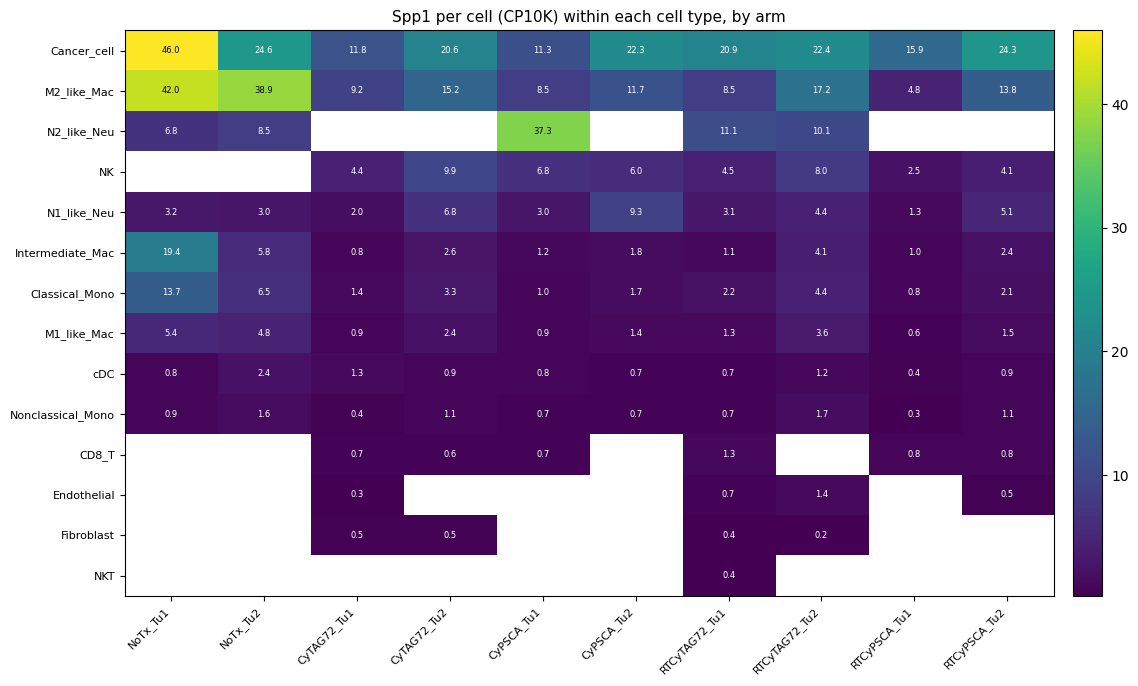

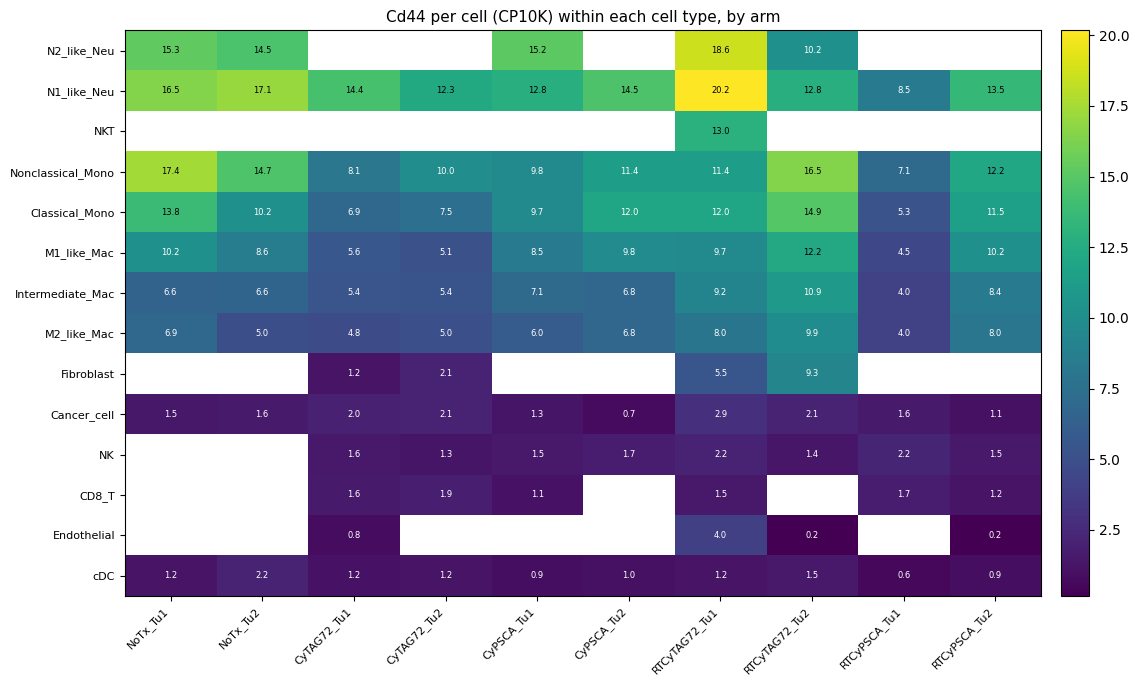

In [24]:
# Heatmap: per-cell expression within each cell type, across arms (only types with enough cells).
for g in GENES:
    piv = (comp_grp[comp_grp["gene"] == g]
           .pivot_table(index="celltype", columns="group", values="mean_per_cell", observed=True))
    piv = piv.reindex(columns=[c for c in groups if c in piv.columns]).dropna(how="all")
    piv = piv.loc[piv.mean(axis=1).sort_values(ascending=False).index]
    if piv.empty:
        continue
    data = piv.values.astype(float)
    fig, ax = plt.subplots(figsize=(0.75 * data.shape[1] + 4, 0.34 * data.shape[0] + 2.2))
    im = ax.imshow(data, cmap="viridis", aspect="auto")
    ax.set_xticks(range(data.shape[1])); ax.set_xticklabels(piv.columns, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(data.shape[0])); ax.set_yticklabels(piv.index, fontsize=8)
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            if np.isfinite(data[i, j]):
                ax.text(j, i, f"{data[i,j]:.1f}", ha="center", va="center", fontsize=6,
                        color="w" if data[i, j] < np.nanmax(data) * 0.6 else "k")
    ax.set_title(f"{g} per cell (CP10K) within each cell type, by arm", fontsize=11)
    fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    fig.tight_layout(); fig.savefig(FIG_DIR / f"sc_{g.lower()}_by_celltype_condition.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close(fig)

## 8. Summary

In [ ]:
mac_pool = (comp_grp[(comp_grp["gene"] == "Spp1") & (comp_grp["celltype"].isin(MAC_LABELS))]
            .groupby("group", observed=True)["pct_of_pool"].sum().reindex(groups))
tum_pool = (comp_grp[(comp_grp["gene"] == "Spp1") & (comp_grp["celltype"] == TUMOUR_LABEL)]
            .set_index("group")["pct_of_pool"].reindex(groups))
cd44_mac = (comp_grp[(comp_grp["gene"] == "Cd44") & (comp_grp["celltype"].isin(MAC_LABELS))]
            .groupby("group", observed=True)["pct_of_pool"].sum().reindex(groups))

print(f"""
==================== SUMMARY — report these back ====================
Design      : {len(design)} samples / {design['mouse'].nunique()} mice / {len(CONDITION_ORDER)} arms x 2 tumours x 3 reps
Missing     : {missing if missing else 'none'}
Annotation  : {CT_COL}   Units: linear CP10K (expm1 of log-normalised .X)

Spp1 pool share, macrophages vs tumour, per arm (%):
{pd.DataFrame({'mac_%_of_Spp1': mac_pool, 'tumour_%_of_Spp1': tum_pool, 'mac_%_of_Cd44': cd44_mac}).round(1).to_string()}

Per-cell means by arm:
{by_group[['group','Spp1_mean','Spp1_pct_pos','Cd44_mean','Cd44_pct_pos','n_reps']].round(3).to_string(index=False)}

WHAT TO READ
 1. Sec 4 - is the Spp1 pool tumour-dominated in EVERY arm, or does the macrophage share rise with
    treatment? 01c/01d found tumour ~53% pooled; this says whether that holds arm by arm.
 2. Sec 5 - for any arm where the macrophage Spp1 share moves, was it 'abundance' (more macs
    recruited) or 'per-cell' (same macs, more Spp1 each = a state change)? Only the second is a
    reprogramming claim; the PDF's model predicts the second.
 3. Sec 6 - the abscopal test, paired within mouse. A consistent Tu2-vs-Tu1 delta in the RT arms
    with ~0 delta in the non-RT arms is the Spp1/Cd44 readout of the abscopal effect.
 4. Sec 7 - RTCyPSCA vs CyPSCA isolates RT with CAR-T held constant; PSCA vs TAG72 isolates CAR-T
    specificity. TAG72 is the control that makes any PSCA-specific claim interpretable.

CAVEAT: single-cell is dissociated, so cell-type proportions are capture-biased, not tissue truth
(macrophages and tumour dissociate differently). 'pct_of_pool' inherits that bias; 'mean_per_cell'
does NOT and is the safer cross-arm comparison. For tissue-weighted contribution per arm, the
spatial object would need per-condition cell counts - a follow-up, not this notebook.
=====================================================================
""")


==================== SUMMARY — report these back ====================
Design      : 29 samples / 15 mice / 5 arms x 2 tumours x 3 reps
Missing     : ['CyTAG72_Tu1_2']
Annotation  : cell_type_lvl2   Units: linear CP10K (expm1 of log-normalised .X)

Spp1 pool share, macrophages vs tumour, per arm (%):
               mac_%_of_Spp1  tumour_%_of_Spp1  mac_%_of_Cd44
group                                                        
NoTx_Tu1           43.200001         45.000000      22.900000
NoTx_Tu2           36.400002         52.099998      20.900000
CyTAG72_Tu1        75.500000         13.600000      55.700001
CyTAG72_Tu2        67.300003         15.900000      45.799999
CyPSCA_Tu1         60.799999         16.900000      43.400002
CyPSCA_Tu2         52.599998         27.600000      46.400002
RTCyTAG72_Tu1      61.599998         19.299999      53.400002
RTCyTAG72_Tu2      67.199997         11.400000      46.599998
RTCyPSCA_Tu1       57.400002         28.799999      56.000000
RTCyPSCA_Tu2    

: 